# Bitcoin Market Sentiment vs Trader Performance Analysis  
### Primetrade.ai Round-0 Assignment  

**Name:** Akanksha Chougule  
**Tools Used:** Python, Pandas, Matplotlib  

## Objective

To analyze how Bitcoin market sentiment (Fear & Greed Index) impacts trader performance using historical trading data.

In [34]:
import pandas as pd

# Load datasets
fear_greed = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

# Show first 5 rows
print("Fear & Greed Dataset:")
print(fear_greed.head())

print("\nTrades Dataset:")
print(trades.head())

Fear & Greed Dataset:
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

Trades Dataset:
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       1

In [35]:
print("Fear & Greed Columns:")
print(fear_greed.columns)

print("\nTrades Columns:")
print(trades.columns)

print("\nFear & Greed Info:")
print(fear_greed.info())

print("\nTrades Info:")
print(trades.info())

Fear & Greed Columns:
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

Trades Columns:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

Fear & Greed Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None

Trades Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ----

In [36]:
fear_greed.columns = fear_greed.columns.str.strip().str.lower()
trades.columns = trades.columns.str.strip().str.lower()

print(fear_greed.columns)
print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp'],
      dtype='object')


In [37]:
fear_greed.columns = fear_greed.columns.str.strip().str.lower().str.replace(" ", "_")
trades.columns = trades.columns.str.strip().str.lower().str.replace(" ", "_")

print(fear_greed.columns)
print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')


In [38]:
fear_greed['date'] = pd.to_datetime(fear_greed['date']).dt.date

trades['timestamp_ist'] = pd.to_datetime(
    trades['timestamp_ist'],
    dayfirst=True
)

trades['date'] = trades['timestamp_ist'].dt.date

print(fear_greed.head())
print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      account  coin  execution_price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   size_tokens  size_usd side       timestamp_ist  start_position direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 2

## Data Preprocessing

- Cleaned column names  
- Converted timestamps to datetime format  
- Extracted date for merging  

## Data Merging

Merged trader dataset with sentiment dataset using date as the key.  
Each trade is now associated with a market sentiment label.

In [39]:
merged = pd.merge(trades, fear_greed[['date', 'classification']], on='date', how='left')

print(merged.head())
print(merged.shape)

                                      account  coin  execution_price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   size_tokens  size_usd side       timestamp_ist  start_position direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   closed_pnl                                   transaction_hash     order_id  \
0         0

## Performance Analysis

Analyzing trader performance across different sentiment categories using:

- Average Profit (PnL)
- Win Rate
- Trade Volume

In [40]:
summary = merged.groupby("classification").agg(
    total_trades = ("closed_pnl", "count"),
    avg_pnl = ("closed_pnl", "mean"),
    total_pnl = ("closed_pnl", "sum"),
    win_rate = ("closed_pnl", lambda x: (x > 0).mean() * 100),
    avg_fee = ("fee", "mean"),
    avg_trade_size = ("size_usd", "mean")
).round(2)

print(summary)

                total_trades  avg_pnl   total_pnl  win_rate  avg_fee  \
classification                                                         
Extreme Fear           21400    34.54   739110.25     37.06     1.12   
Extreme Greed          39992    67.89  2715171.31     46.49     0.68   
Fear                   61837    54.29  3357155.44     42.08     1.50   
Greed                  50303    42.74  2150129.27     38.48     1.25   
Neutral                37686    34.31  1292920.68     39.70     1.04   

                avg_trade_size  
classification                  
Extreme Fear           5349.73  
Extreme Greed          3112.25  
Fear                   7816.11  
Greed                  5736.88  
Neutral                4782.73  


## Average Profit by Sentiment

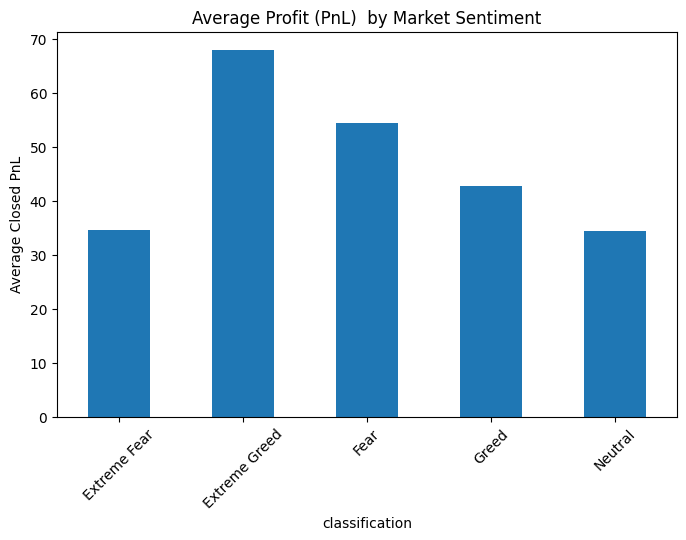

In [41]:
import matplotlib.pyplot as plt

summary["avg_pnl"].plot(kind="bar", figsize=(8,5), title="Average Profit (PnL)  by Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=45)
plt.show()

## Win Rate by Sentiment

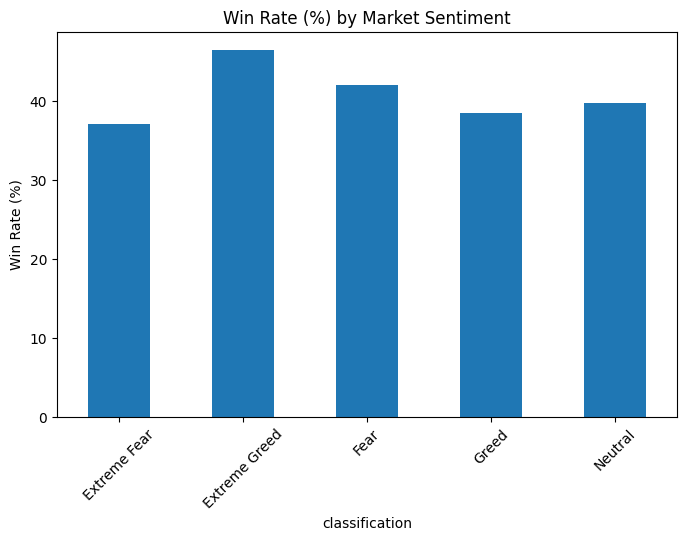

In [42]:
win_rate = merged.groupby("classification")["closed_pnl"].apply(lambda x: (x > 0).mean() * 100)

win_rate.plot(kind="bar", figsize=(8,5), title="Win Rate (%) by Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.xticks(rotation=45)
plt.show()

## Trade Volume Analysis

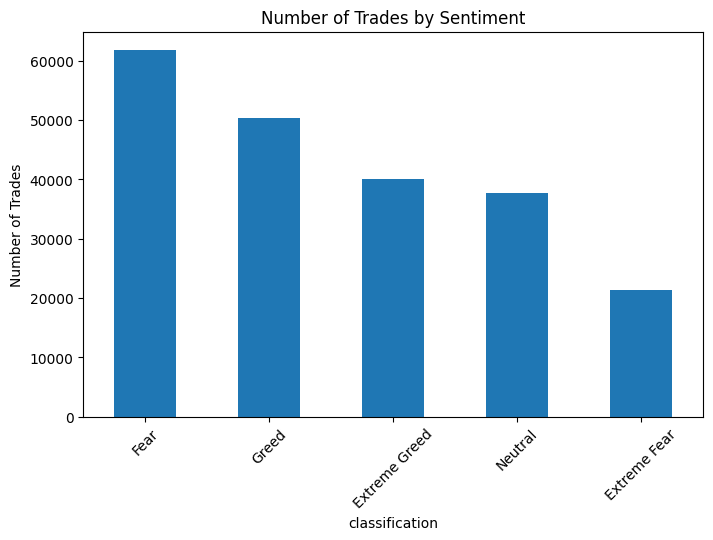

In [43]:
trade_count = merged["classification"].value_counts()

trade_count.plot(kind="bar", figsize=(8,5), title="Number of Trades by Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)
plt.show()

In [44]:
summary = merged.groupby("classification").agg(
    total_trades = ("closed_pnl", "count"),
    avg_pnl = ("closed_pnl", "mean"),
    total_pnl = ("closed_pnl", "sum"),
    win_rate = ("closed_pnl", lambda x: (x > 0).mean() * 100)
).round(2)

summary

,total_trades,avg_pnl,total_pnl,win_rate
classification,,,,
Extreme Fear,21400,34.54,739110.25,37.06
Extreme Greed,39992,67.89,2715171.31,46.49
Fear,61837,54.29,3357155.44,42.08
Greed,50303,42.74,2150129.27,38.48
Neutral,37686,34.31,1292920.68,39.70


## Key Insights

- Extreme Greed markets produce the highest average profit per trade
- Fear conditions also show strong profitability due to volatility
- Neutral markets show weaker performance due to lack of clear direction
- Trade volume is highest during Fear conditions

## Conclusion

Market sentiment significantly impacts trading performance.  
Strong directional markets (Greed / Extreme Greed) offer better profitability,  
while Neutral and Extreme Fear conditions reduce trading efficiency.

These insights can help traders adapt strategies based on market sentiment.